[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lanzlagman/intro-python-astro-PUP/blob/main/solutions/05_traditional_ml_astrophysics.ipynb)

> **Solutions copy.** Every **YOUR TURN** cell below is already filled in. Work through `notebooks/` first; read this afterwards.

# Notebook 05: Overview of Traditional ML in Astrophysics

**Computational and Data-driven Astrophysics: A Practical Python Workshop**
PUP Physics Society · 15 August 2026

---

Notebook 04 ended with a cluster that every human in the room could see and no line of code
could find. This notebook draws the boundary.

Before we import anything, a piece of history that reframes the whole topic.

> ### Where this all started
>
> Stellar classification was built at Harvard, by hand. **Pickering** and **Fleming** labelled
> spectra A, B, C… by hydrogen line strength; **Maury** rearranged them by line width; **Annie
> Jump Cannon** reordered the sequence to **O B A F G K M** and added decimal subdivisions.
>
> Cannon classified roughly **200,000 spectra between 1911 and 1914**. No computers.
>
> Here is the part that matters for this notebook. Cannon was sorting by the *appearance* of
> hydrogen lines, not by temperature: nobody knew the physical basis yet. The temperature
> ordering **fell out of the data**. It was discovered, not designed.
>
> A decade later **Hertzsprung** and **Russell**, independently, plotted luminosity against
> spectral type and found that stars occupy narrow bands rather than filling the plane.
>
> | What they did | What we would call it now |
> |---|---|
> | Cannon: assign 200,000 spectra to a label set | **supervised classification**, by hand |
> | The temperature ordering emerging unbidden | **structure discovery** |
> | Hertzsprung & Russell: find bands in a scatter plot | **unsupervised learning** |
> | The H–R diagram itself | a **2-D projection** of a high-dimensional space |
>
> **Machine learning is not being imported into astronomy.** Astronomy has been doing this
> since 1901. What changed is the catalogue size: Cannon had 200,000 objects and three years.
> Gaia has 1.8 billion.

---
### The wider map

Finding a cluster is one problem out of many. Almost every task in observational astrophysics
that used to be done by eye, one object at a time, is now a supervised or unsupervised learning
problem, and the split is simply whether labelled examples exist.

**Supervised: you have labelled examples and want to generalise from them.**

| Task | Type | The idea |
|---|---|---|
| Photometric redshifts | regression | predict a galaxy's redshift from broadband colours, because spectra for a billion galaxies are impossible |
| Stellar parameters from spectra | regression | infer $T_{\text{eff}}$, $\log g$, [Fe/H] directly from the spectrum, trained on a set with known values |
| Star/galaxy separation | classification | decide whether a faint source is a point or extended, at the depth where the image alone is ambiguous |
| Transient classification | classification | is this rising light curve a supernova, a flare, or an asteroid? Surveys issue millions of alerts a night |
| Variable star typing | classification | RR Lyrae, Cepheid, eclipsing binary, from the shape of the folded light curve |
| Strong lens finding | classification | pick the rare arcs out of millions of images |
| Galaxy morphology | classification | the Galaxy Zoo problem: volunteers labelled a training set, models scaled it |

**Unsupervised: no labels, and the structure has to declare itself.**

| Task | Type | The idea |
|---|---|---|
| Moving groups and stellar streams | clustering | the same argument as this notebook, applied to the halo instead of the disc |
| Spectral archetypes | dimensionality reduction | PCA or an autoencoder on millions of spectra, to find the handful of axes that actually vary |
| Survey visualisation | manifold learning | t-SNE or UMAP to lay out a catalogue in two dimensions and see what clumps |
| Anomaly detection | outlier detection | flag the objects that fit no known class, which is how genuinely new phenomena get found |
| Deblending crowded fields | source separation | decide how many objects produced one blob of light |

Two things are worth noticing. The **same algorithm serves different sciences**: the density
clustering below finds open clusters, and the same idea on halo stars finds tidal streams.
And the **hard part is rarely the model**. It is deciding which columns encode the physics,
what the labels actually mean, and how the sample was selected. That is the theme of the rest
of this notebook.

## Part 0: Setup and data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import ParameterGrid

RAW = "https://raw.githubusercontent.com/lanzlagman/intro-python-astro-PUP/main/data/"


def load_workshop_data(filename):
    """Local file first, then GitHub. Works identically in Colab and locally."""
    for path in (f"data/{filename}", f"../data/{filename}"):
        if os.path.exists(path):
            print(f"loaded from disk: {path}")
            return pd.read_csv(path)
    print(f"downloading {filename} from GitHub")
    return pd.read_csv(RAW + filename)


if os.path.exists("data/pleiades_query_result.csv"):
    stars = pd.read_csv("data/pleiades_query_result.csv")
    print("using the file you created in Notebook 02")
else:
    stars = load_workshop_data("gaia_pleiades.csv")
    stars = stars[(stars["parallax_over_error"] > 5) & (stars["ruwe"] < 1.4)].copy()

stars["M_G"] = stars["phot_g_mean_mag"] - 5 * np.log10(1000 / stars["parallax"]) + 5

print(f"{len(stars)} stars in the field")

using the file you created in Notebook 02
5180 stars in the field


---
## Part 1: Unsupervised: finding the cluster nobody labelled

The argument is physical, not statistical. Cluster members formed **together**, from **one** cloud, at **one** time. So they share a position on the sky, a distance, and a velocity. Field stars share none of these. That gives us five natural features: `ra`, `dec`, `parallax`, `pmra`, `pmdec`.

Note what is **absent**: brightness and colour. We deliberately do *not* use them. If we find the cluster using only astrometry, the colour–magnitude diagram of the members is an **independent prediction** we can check. Using colour to find the cluster and then celebrating that the members form a main sequence would be circular reasoning.

That restraint: hold something back so you have something to test against, is the difference between a result and a demo.

---
## Part 2: The preprocessing pipeline

Before any model sees the data, the features have to be put into a state it can use.

### Why the raw columns cannot be handed over as they are

The five features carry different units and ranges: `ra` and `dec` cover a couple of degrees,
`parallax` sits near 7 mas, `pmdec` runs across roughly 60 mas/yr. DBSCAN computes a Euclidean
distance across all columns at once, so on raw data it would be dominated by whichever column
carries the largest numbers, which is a fact about units rather than about stars. A missing
value would also stop the estimator outright, so imputation goes in front of the scaler.

### Why this belongs in a `Pipeline`

Calling `fit_transform` on each step separately works, and is how most people start. Composing
them into one object buys four things:

- **One object carries the whole recipe.** Serialise a fitted pipeline and the entire
  transformation is preserved, not just the last model.
- **The order is recorded, not remembered.** Imputing after scaling differs from imputing
  before it. In a pipeline that order is a property of the object rather than of which cells
  you happened to run.
- **It is the standard defence against leakage.** Transformation statistics must come from the
  training data alone; inside a pipeline, `fit` and `transform` stay separated across
  cross-validation folds without you arranging it. That does not bite the unsupervised fit
  below, which sees all the data by construction, but it is why pipelines are near-mandatory in
  supervised work.
- **Steps become swappable and addressable.** Exchanging a scaler is one line, and every
  parameter is reachable by name, so `clustering__eps` can be handed to a parameter search.

### Different columns deserve different treatment

A single `Pipeline` applies the same steps to every column, which is rarely what you want. Our
features split into two physically distinct groups: **position** (`ra`, `dec`), roughly uniform
because the query was a cone search, and **kinematics** (`parallax`, `pmra`, `pmdec`), sharply
peaked for members with long tails from field stars.

`ColumnTransformer` routes each group through its own sub-pipeline. It is the component almost
every production preprocessing stage contains, and in a table with categorical columns it is
what lets you one-hot encode those while scaling the numeric ones in a single object.

Here it earns its place through the scaler. `StandardScaler` uses the mean and standard
deviation, both pulled around by outliers. `RobustScaler` uses the median and interquartile
range, which tails barely move. The cell below quantifies the difference first: for a Gaussian,
std/IQR is about 0.74, and a value well above that is evidence of tails.

### A caveat about scope

In real work **this stage consumes the most time.** Feature selection, missing-value policy,
scaler choice, encoding, outlier handling, and checking what each choice does downstream is
iterative and rarely settled on the first attempt. It routinely outweighs the modelling, and
the result depends on it more than on the choice of algorithm.

What follows is a **minimal working template**: the smallest structure that is still the right
shape.

In [2]:
POSITION   = ["ra", "dec"]                       # degrees, roughly uniform
KINEMATICS = ["parallax", "pmra", "pmdec"]       # peaked, with heavy field-star tails
FEATURES   = POSITION + KINEMATICS

X = stars[FEATURES]

# Evidence for the scaler choice, before making it.
# For a normal distribution std/IQR ~ 0.74; well above that means heavy tails.
print(f"{'feature':10s} {'std':>9s} {'IQR':>9s} {'std/IQR':>9s}   tails?")
print("-" * 52)
for name in FEATURES:
    col = X[name].dropna()
    iqr = col.quantile(0.75) - col.quantile(0.25)
    ratio = col.std() / iqr
    print(f"{name:10s} {col.std():9.3f} {iqr:9.3f} {ratio:9.2f}   "
          f"{'yes' if ratio > 1.0 else 'no'}")

# Each block gets its own sub-pipeline.
position_block = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),                # near-uniform: mean and std are fine
])

kinematic_block = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  RobustScaler()),                  # heavy tails: use median and IQR
])

preprocessor = ColumnTransformer([
    ("position",   position_block,  POSITION),
    ("kinematics", kinematic_block, KINEMATICS),
])

X_prepared = preprocessor.fit_transform(X)

print("\nstructure:")
for name, block, columns in preprocessor.transformers:
    steps = " -> ".join(s.__class__.__name__ for _, s in block.steps)
    print(f"   {name:11s} {columns}")
    print(f"   {'':11s}   {steps}")

print(f"\nmissing values in the feature block: {int(X.isna().sum().sum())}")
print(f"output shape: {X_prepared.shape}  (column order follows the transformer list)")

feature          std       IQR   std/IQR   tails?
----------------------------------------------------
ra             0.548     0.892      0.61   no
dec            0.496     0.784      0.63   no
parallax       2.165     1.044      2.07   yes
pmra          13.071     8.138      1.61   yes
pmdec         14.857     8.639      1.72   yes

structure:
   position    ['ra', 'dec']
                 SimpleImputer -> StandardScaler
   kinematics  ['parallax', 'pmra', 'pmdec']
                 SimpleImputer -> RobustScaler

missing values in the feature block: 0
output shape: (5180, 5)  (column order follows the transformer list)


> **On the imputer doing nothing.** This table has already been cleaned, so median imputation
> is a no-op and the printed count of missing values is zero. It stays in regardless. Including
> it costs one line now; omitting it costs a crash the first time the pipeline meets a table
> with a gap in it, which is every table you did not prepare yourself. A template should contain
> the steps a real run will need, not only the steps this run happens to need.
>
> **On the column order.** `ColumnTransformer` emits its blocks in the order they are listed, so
> the output columns are `ra, dec, parallax, pmra, pmdec` regardless of how they sat in the
> original table. Worth knowing before you index into the array by position.
>
> **On what changed.** Swapping one scaler for another altered the geometry of the space DBSCAN
> works in, so the `eps` that suits it is not the same number as before. That is precisely why
> the parameters are derived in Part 4 rather than carried over.

---
## Part 3: Fitting the model

The estimator becomes the final step of the same pipeline. Preprocessing and clustering are now
one object with one `fit`.

**DBSCAN** (*Density-Based Spatial Clustering of Applications with Noise*) suits this problem
for three reasons: it is not told how many clusters to find, it has an explicit **noise** label
so field stars are not forced into a group, and it accepts clusters of any shape.

It takes two parameters. `eps` is the radius, in scaled units, within which points count as
neighbours; `min_samples` is how many neighbours make a region dense. The values used here are
**provisional**, chosen only to get the machinery running. Part 4 derives both properly, which
is a piece of work in its own right.

In [3]:
# The full pipeline: preprocessing plus the estimator, as one object.
pipeline = Pipeline([
    ("prep",       preprocessor),
    ("clustering", DBSCAN(eps=0.5, min_samples=12)),   # provisional; Part 4 derives both
])

stars["label"] = pipeline.fit_predict(X)

sizes = stars[stars["label"] >= 0]["label"].value_counts()
n_noise = int((stars["label"] == -1).sum())

print(f"clusters found : {len(sizes)}")
print(f"labelled noise : {n_noise}  ({100*n_noise/len(stars):.1f}% of the field)\n")

print("three largest:")
for lab, n in sizes.head(3).items():
    g = stars[stars["label"] == lab]
    print(f"   cluster {lab:>3}  {n:>5} stars   "
          f"d = {1000/g['parallax'].median():5.0f} pc   "
          f"pm = ({g['pmra'].median():6.2f}, {g['pmdec'].median():7.2f}) mas/yr")

if len(sizes) > 3:
    print(f"   ... and {len(sizes)-3} smaller groups of "
          f"{sizes.iloc[3:].min()}-{sizes.iloc[3:].max()} stars each")

clusters found : 2
labelled noise : 2006  (38.7% of the field)

three largest:
   cluster   0   2808 stars   d =  1474 pc   pm = (  1.82,   -3.42) mas/yr
   cluster   1    366 stars   d =   136 pc   pm = ( 19.85,  -45.35) mas/yr


> **This is what untuned parameters look like.** Depending on the field, the provisional
> settings will either find the cluster buried among a scatter of small spurious groups, or miss
> it entirely. Nothing here is broken: `eps = 0.5` was a number typed into a cell, and DBSCAN
> did exactly what it was asked.
>
> That is the motivation for Part 4. The two parameters are not conveniences to be guessed; they
> define what the algorithm means by "dense", and they have to be derived.
>
> Notice also what the pipeline made cheap. The scaler in Part 2 changed, and this cell did not,
> because the estimator only ever sees whatever the preprocessing block hands it.

---
## Part 4: Choosing the parameters

The values used above were provisional. DBSCAN has two, and neither should be guessed:
`min_samples`, how many neighbours make a region dense, and `eps`, the radius in scaled units
within which points count as neighbours.

They are derived in two stages: a standard diagnostic narrows `eps` to a sensible range, then a
small grid search picks the pair that best separates the cluster from the background.

### Stage 1: the k-distance plot

`eps` lives in scaled units with no physical meaning, so it cannot be guessed. The standard
diagnostic: for every point, measure the distance to its **k-th nearest neighbour**, sort those
distances, and plot them. Points in dense regions have close neighbours, so the curve is flat
and low; points in sparse regions have distant ones, so it turns upward at the end. **The elbow
is the scale at which the data stops being dense.**

> **Read the elbow as an upper bound, not as the answer.** It describes the density of the
> sample as a whole, and this sample is mostly field stars. The field is itself a large, fairly
> dense blob, so the elbow reports *its* density. The open cluster is a much tighter structure
> inside that, and separating it needs an `eps` well below the elbow.
>
> This is the general case, not an accident of this dataset: when the structure you want is
> denser than the background it sits in, a global density diagnostic overestimates the scale you
> need. So the elbow sets the **top** of the search range, and the grid is spaced logarithmically
> below it.

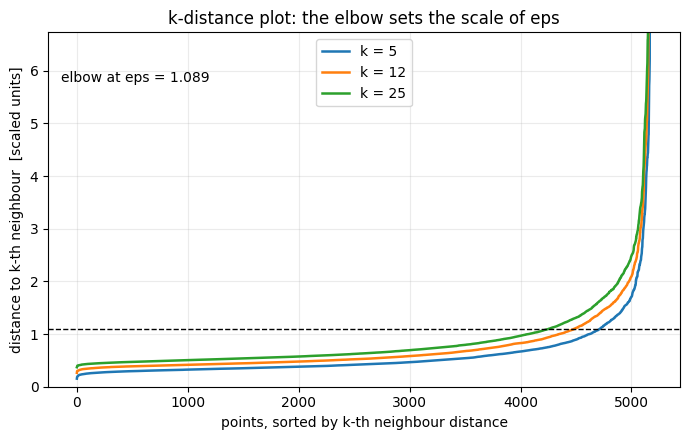

elbow at k = 12: eps ~ 1.089   (upper bound)
search range: 0.0327 to 1.3074, 14 values


In [4]:
def k_distances(Z, k):
    """Sorted distance from each point to its k-th nearest neighbour."""
    nn = NearestNeighbors(n_neighbors=k).fit(Z)
    d, _ = nn.kneighbors(Z)
    return np.sort(d[:, -1])


def find_knee(d, trim=99.0):
    """Point of the curve furthest below the chord joining its endpoints.

    The top of a k-distance curve is a handful of isolated outliers whose
    distances are far larger than anything else. Left in, they dominate the
    normalisation and flatten the real elbow, so trim before measuring.
    """
    d = d[d <= np.percentile(d, trim)]
    x = np.linspace(0, 1, len(d))
    y = (d - d.min()) / (d.max() - d.min())
    return d[np.argmax(x - y)]


K_REF = 12                                  # the min_samples we read the elbow at

fig, ax = plt.subplots(figsize=(7, 4.5))
for k in (5, K_REF, 25):
    d = k_distances(X_prepared, k)
    ax.plot(np.arange(len(d)), d, lw=1.8, label=f"k = {k}")

d_ref = k_distances(X_prepared, K_REF)
eps_knee = find_knee(d_ref)
ax.axhline(eps_knee, ls="--", color="k", lw=1)
ax.annotate(f"elbow at eps = {eps_knee:.3f}", xy=(0, eps_knee),
            xytext=(0.02, 0.86), textcoords="axes fraction")

ax.set_xlabel("points, sorted by k-th neighbour distance")
ax.set_ylabel("distance to k-th neighbour  [scaled units]")
ax.set_title("k-distance plot: the elbow sets the scale of eps")
ax.set_ylim(0, np.percentile(d_ref, 99.5))
ax.legend(loc='upper center')
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

# The elbow is the ceiling. Search logarithmically below it.
eps_grid = np.round(np.geomspace(0.03 * eps_knee, 1.2 * eps_knee, 14), 4)

print(f"elbow at k = {K_REF}: eps ~ {eps_knee:.3f}   (upper bound)")
print(f"search range: {eps_grid[0]} to {eps_grid[-1]}, {len(eps_grid)} values")

### Stage 2: a scored grid search

The elbow gives a ceiling, not an answer, and says nothing about `min_samples`. Both are settled
by scoring every combination against a criterion fixed in advance.

**Not** "the run must find exactly one cluster". At any `eps` tight enough to isolate the open
cluster, the dense core of the field breaks into fragments of its own. Those are not failures;
they are what a density algorithm does to a background that has structure. Demanding a single
cluster throws away every fit that worked.

Instead, score each cluster a fit produces by how far it sits from everything else, in units of
its own dispersion, in the proper-motion plane:

$$ S = \frac{\left|\vec{\mu}_{\text{group}} - \vec{\mu}_{\text{rest}}\right|}
            {\sigma_{\text{group}}} $$

The fit is judged by its **best** group, and that group is the candidate. Two size constraints
keep it honest: a candidate holds at least **100** stars, so the search cannot win on a handful
of points in one dense pixel, and at most **half** the sample, so it cannot win by relabelling
the field.

`ParameterGrid` expands the combinations and `set_params` addresses them by step name. This is
the shape of `GridSearchCV`, written by hand because there are no labels to cross-validate
against.

In [ ]:
MIN_MEMBERS = 100          # not a handful of stars in the densest pixel
MAX_FRACTION = 0.5         # not the whole field relabelled as one cluster


def score_fit(labels):
    """Best-separated cluster in a fit: returns (label, S).

    Every cluster is scored against everything not in it. Fragments of the
    field score poorly because they sit on top of the bulk of the sample.
    """
    best_label, best_S = None, np.nan

    for lab in {l for l in labels if l >= 0}:
        in_group = labels == lab
        size = int(in_group.sum())
        if size < MIN_MEMBERS or size > MAX_FRACTION * len(labels):
            continue

        group, rest = stars[in_group], stars[~in_group]
        separation = np.hypot(group["pmra"].median() - rest["pmra"].median(),
                              group["pmdec"].median() - rest["pmdec"].median())
        dispersion = np.hypot(group["pmra"].std(), group["pmdec"].std())
        if dispersion <= 0:
            continue

        S = separation / dispersion
        if np.isnan(best_S) or S > best_S:
            best_label, best_S = lab, S

    return best_label, best_S


# YOUR TURN: add values to either list and re-run
grid = ParameterGrid({
    "clustering__eps":         list(eps_grid),
    "clustering__min_samples": [5, 8, 12, 16, 20, 25, 30, 40],
})

results = []
for params in grid:
    pipeline.set_params(**params)
    lab = pipeline.fit_predict(X)
    best_label, S = score_fit(lab)
    results.append({
        "eps": params["clustering__eps"],
        "min_samples": params["clustering__min_samples"],
        "clusters": len({l for l in lab if l >= 0}),
        "candidate": int((lab == best_label).sum()) if best_label is not None else 0,
        "S": S,
    })

scan = pd.DataFrame(results)
valid = scan.dropna(subset=["S"])

print(f"{len(scan)} combinations tried, {len(valid)} produced a viable candidate\n")
print("best five:")
print(valid.sort_values("S", ascending=False).head(5).to_string(index=False))

if len(valid):
    best = valid.loc[valid["S"].idxmax()]
    EPS, MIN_SAMPLES = float(best["eps"]), int(best["min_samples"])
else:
    EPS, MIN_SAMPLES = float(eps_grid[0]), K_REF
    print("\n" + "!" * 70)
    print("NO COMBINATION PRODUCED A VIABLE CANDIDATE.")
    print("The figure below is NOT a result. Widen eps_grid downward")
    print("(lower the 0.03 factor) and re-run.")
    print("!" * 70)

# Refit at the chosen settings and keep only the winning cluster.
pipeline.set_params(clustering__eps=EPS, clustering__min_samples=MIN_SAMPLES)
labels = pipeline.fit_predict(X)
winner, S_final = score_fit(labels)

stars["label"] = np.where(labels == winner, 1, -1) if winner is not None else -1
members = stars[stars["label"] == 1]
field = stars[stars["label"] == -1]

if EPS in (eps_grid[0], eps_grid[-1]):
    print("\nWARNING: the best eps sits at the edge of the search range.")
    print("The optimum may lie outside it. Widen eps_grid and re-run.")

print(f"\nselected: eps = {EPS:.4f}, min_samples = {MIN_SAMPLES}")
print(f"the fit found {len({l for l in labels if l >= 0})} clusters; "
      f"cluster {winner} is the candidate (S = {S_final:.1f})")
print(f"{len(members)} members, {len(field)} everything else")
if len(members):
    print(f"cluster distance: {1000/members['parallax'].median():.0f} pc")

> **The other clusters are not a problem.** The chosen fit usually reports several groups. The
> large one near the origin of the proper-motion plane is the core of the field population, dense
> enough to register as a cluster without being one physically. It scores near zero on $S$
> because it sits on top of everything else, which is how the criterion is meant to treat it.
> Only the winning group reaches the figure.
>
> **Read the spread of the top five, not only the winner.** Similar scores among neighbouring
> combinations mean the result is stable. A winner towering over its neighbours means the fit is
> balanced on one setting and deserves suspicion.
>
> **Watch for a winner at the edge of the grid**, where the search was bounded by the range
> rather than by the data. The cell warns when this happens. $S$ rewards tightness, so it pushes
> `eps` down until the 100-member floor stops it: the criterion encodes a preference, and a
> different one would return a different membership list.
>
> **The textbook distance to the Pleiades is 130 pc.** The algorithm was never told where the
> cluster was, how far away it was, or that there was one.

## Part 5: Visualizing the Results

Three panels, each showing the whole field in grey with the recovered members in red.

| Panel | Axes | What it shows |
|---|---|---|
| Sky | `ra`, `dec` | members concentrated, field spread across the frame |
| Proper motion | `pmra`, `pmdec` | the clump, now with a boundary drawn around it |
| Colour–magnitude | `bp_rp`, `M_G` | the independent check: neither axis was a feature |

One more decision worth making explicitly: **axis limits.** Left to itself, matplotlib fits
every point, so a single star with a wild proper motion compresses the interesting structure
into a corner. Setting the limits from percentiles rather than from the extremes keeps the frame
on the bulk of the distribution. A few outliers fall outside the axes, which is a presentation
choice and not a cut, since nothing was removed from the table.

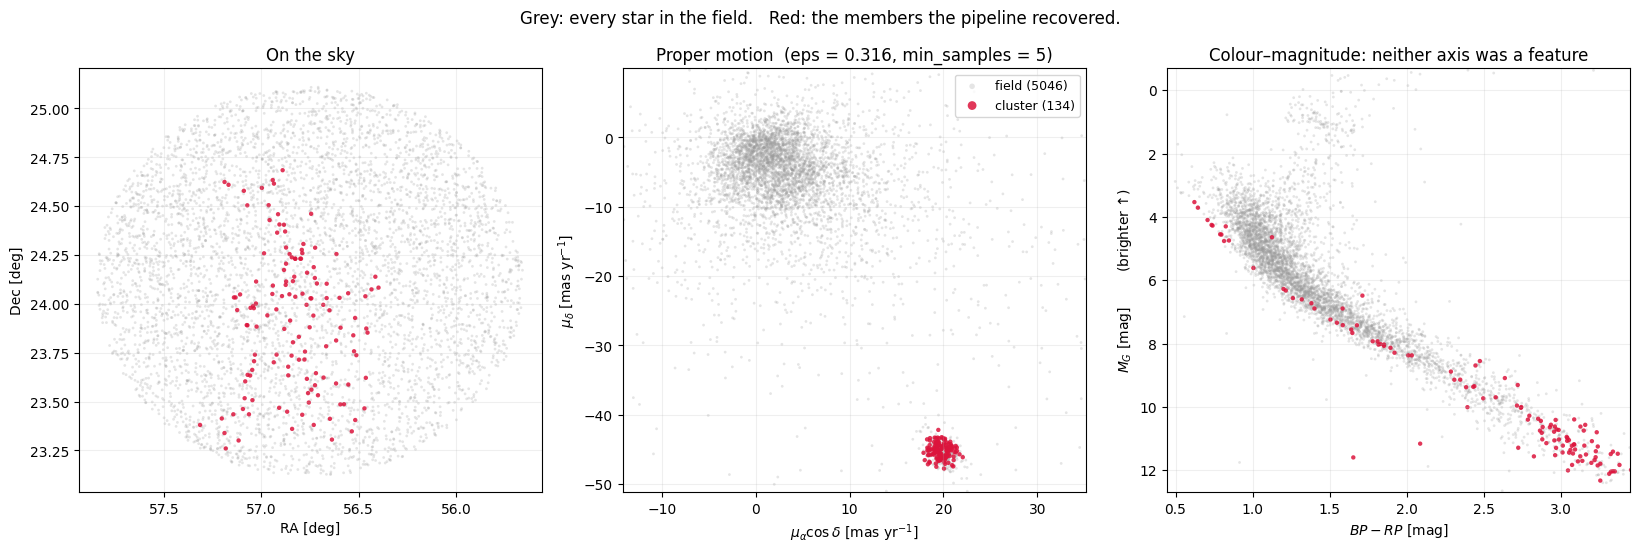

In [6]:
def focus(ax, x, y, lo=1.0, hi=99.0, pad=0.08):
    """Set limits from percentiles, so outliers do not dictate the frame."""
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)];          y = y[np.isfinite(y)]
    x0, x1 = np.percentile(x, [lo, hi])
    y0, y1 = np.percentile(y, [lo, hi])
    ax.set_xlim(x0 - pad * (x1 - x0), x1 + pad * (x1 - x0))
    ax.set_ylim(y0 - pad * (y1 - y0), y1 + pad * (y1 - y0))


FIELD_STYLE = dict(s=4, alpha=0.25, color="0.6", edgecolors="none")
MEMBER_STYLE = dict(s=10, alpha=0.85, color="crimson", edgecolors="none")

fig, (ax_sky, ax_pm, ax_cmd) = plt.subplots(1, 3, figsize=(16.5, 5.6))

# ---------- 1. on the sky ----------
ax_sky.scatter(field["ra"], field["dec"], **FIELD_STYLE)
ax_sky.scatter(members["ra"], members["dec"], **MEMBER_STYLE)
ax_sky.set_xlabel("RA [deg]"); ax_sky.set_ylabel("Dec [deg]")
ax_sky.set_title("On the sky")
focus(ax_sky, stars["ra"], stars["dec"])
ax_sky.invert_xaxis()                      # RA increases to the left

# ---------- 2. proper motion: where the separation lives ----------
ax_pm.scatter(field["pmra"], field["pmdec"], **FIELD_STYLE,
              label=f"field ({len(field)})")
ax_pm.scatter(members["pmra"], members["pmdec"], **MEMBER_STYLE,
              label=f"cluster ({len(members)})")
ax_pm.set_xlabel(r"$\mu_\alpha\cos\delta$ [mas yr$^{-1}$]")
ax_pm.set_ylabel(r"$\mu_\delta$ [mas yr$^{-1}$]")
ax_pm.set_title(f"Proper motion  (eps = {EPS:.3f}, min_samples = {MIN_SAMPLES})")
ax_pm.legend(markerscale=2, fontsize=9, loc="upper right")
focus(ax_pm, stars["pmra"], stars["pmdec"], lo=2, hi=98)

# ---------- 3. the independent check ----------
ax_cmd.scatter(field["bp_rp"], field["M_G"], **FIELD_STYLE)
ax_cmd.scatter(members["bp_rp"], members["M_G"], **MEMBER_STYLE)
ax_cmd.set_xlabel("$BP - RP$ [mag]")
ax_cmd.set_ylabel("$M_G$ [mag]        (brighter ↑)")
ax_cmd.set_title("Colour–magnitude: neither axis was a feature")
focus(ax_cmd, stars["bp_rp"], stars["M_G"])
ax_cmd.invert_yaxis()                      # brighter upwards

for a in (ax_sky, ax_pm, ax_cmd):
    a.grid(alpha=0.2)

fig.suptitle("Grey: every star in the field.   Red: the members the pipeline recovered.",
             fontsize=12)
plt.tight_layout(); plt.show()

> **Read the panels left to right.** On the sky, members concentrate towards the centre while the
> field fills the frame, as a bound cluster should. In proper motion the two populations occupy
> clearly different regions, which is the separation the criterion was written to secure.
>
> **The third panel is the result.** Clustering used position, distance and motion only. Colour
> and magnitude were withheld, yet the members trace a narrow main sequence while the field stars
> scatter. Nothing in the pipeline forced that: one cloud, one epoch, one distance, so differences
> along the sequence are due to mass alone. A physical claim, confirmed by an algorithm told no
> stellar physics.
>
> This is what a **prediction** looks like, as distinct from a **fit**.

---
## What this notebook was, and what it was not

| Step | The template |
|---|---|
| Choose features from a physical argument | position, distance, motion; colour deliberately withheld |
| Route each column group through its own preprocessing | `ColumnTransformer`, scaler chosen from the data |
| Attach the estimator as the final step | `DBSCAN`, addressable as `clustering__eps` |
| Derive the parameters instead of guessing | k-distance plot, then a scored grid |
| Visualise the whole field against the recovered members | three panels, one of them withheld from the fit |

That sequence is the shape of most applied machine learning and changes little with the problem.

**What was left out**, and would be required before calling any of this a result: scoring the
members against an external catalogue, treating the per-star uncertainties the table already
carries, and stating the selection function. The catalogue is not the universe; it is the
universe seen through an instrument with known biases, and a model trained on it learns the
instrument too.

### How this is done for real

Open cluster detection is an active field, and the papers below are close enough to what you
just built to read directly. Note how quickly the methods moved, and that the arguments are
about validation and false positives rather than about the clustering itself.

- **Castro-Ginard et al. (2018)**, *A new method for unveiling open clusters in Gaia*, A&A 618,
  A59 · [arXiv:1805.03045](https://arxiv.org/abs/1805.03045). DBSCAN on the same five astrometric
  features used here, followed by a neural network that classifies each candidate's CMD as a real
  cluster or a chance overdensity. The closest published relative of this notebook, and the
  origin of the OCfinder pipeline that has since reported hundreds of new clusters.
- **Hunt & Reffert (2021)**, *Improving the open cluster census I*, A&A 646, A104 ·
  [arXiv:2012.04267](https://arxiv.org/abs/2012.04267). A head-to-head comparison of DBSCAN,
  HDBSCAN and Gaussian mixture models on Gaia DR2, scored by sensitivity, specificity and
  precision. Read this before choosing a clustering algorithm for anything.
- **Hunt & Reffert (2023)**, *Improving the open cluster census II*, A&A 673, A114. HDBSCAN over
  729 million Gaia DR3 sources, all-sky, validated with a density test and a Bayesian CNN. The
  full-scale version of the workflow above.
- **Krone-Martins & Moitinho (2014)**, *UPMASK*, A&A 561, A57. Membership assignment by repeated
  clustering plus a random-field test, the standard tool before density methods took over.
- **Cantat-Gaudin et al. (2020)**, *Painting a portrait of the Galactic disc with its stellar
  clusters*, A&A 640, A1. What the catalogues get used for once the memberships exist.

The recurring lesson across all of them: the clustering step is the easy part, and most of the
work is proving that what you found is real.

> ### Where this is going
>
> Hubble's morphological classification of galaxies, into ellipticals, spirals, barred spirals
> and irregulars, is another human-built label set applied by eye, for decades, one galaxy at a
> time.
>
> Surveys now image **billions** of galaxies. Classifying them is an active research problem, and
> it is the subject of my own PhD: reframing galaxy morphological classification as a **Visual
> Question Answering** problem, so that a vision–language model is asked *"does this galaxy have
> a bar?"* rather than being asked to emit a class label.
>
> The line from Cannon at Harvard in 1911 to this is unbroken. Same task, same difficulty, four
> orders of magnitude more data.

---
### Sources

Historical and physical background follows Carroll & Ostlie, *An Introduction to Modern Astrophysics*, 2nd ed.: §8.1 (The Formation of Spectral Lines), §8.2 (The Hertzsprung–Russell Diagram), §13.3 (Stellar Clusters), §25.1 (The Hubble Sequence).

### If you want to go deeper
- **Ting (2025), *Statistical Machine Learning for Astronomy:*** arXiv:2506.12230, free, ~677 pages. **The single best next step** if you are heading toward a thesis.
- astroML interactive book · <http://www.astroml.org/astroML-notebooks/>
- scikit-learn user guide, *Pipelines and composite estimators*, and *Clustering*